In [36]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [30]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(
    root="/datasets/apollo2506/eurosat-dataset/EuroSAT",
    transform=transform
)

In [33]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)- train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [34]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
model = resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("model/best_model.pth"))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


We grab a few images from the validation loader.

In [37]:
model.eval()

images, labels = next(iter(val_loader))

images, labels = images.to(device), labels.to(device)

Get Model predictions

In [38]:
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

Moving images back to CPU as matplotlib cannot display GPU tensors

In [40]:
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

Plot predictions

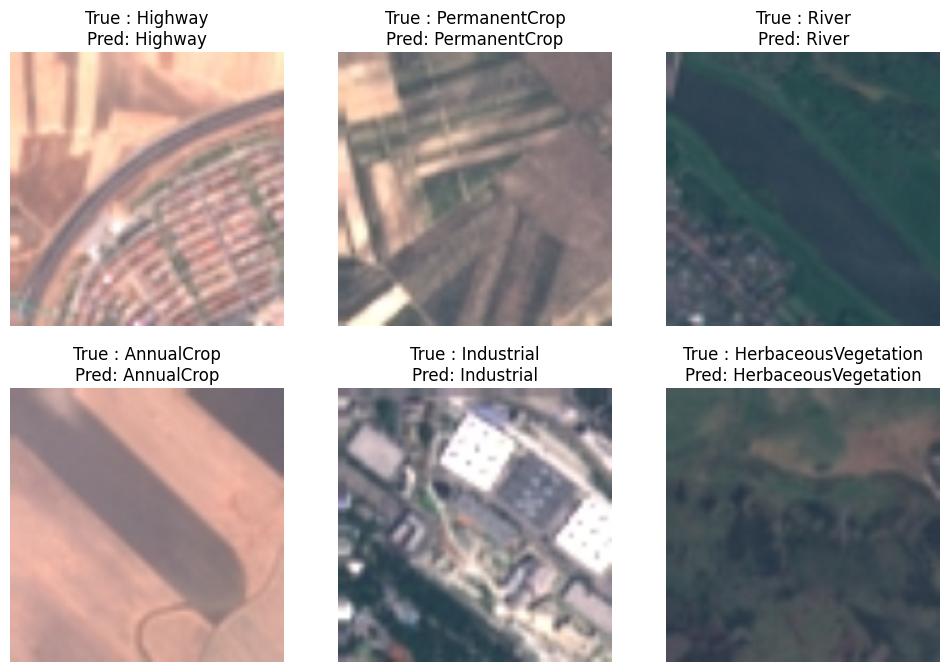

In [41]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3, i+1)
    
    img = images[i].permute(1,2,0)
    
    plt.imshow(img)
    
    true_label = dataset.classes[labels[i]]
    pred_label = dataset.classes[preds[i]]
    
    plt.title(f"True : {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.show()